hematopoiesis绘制指标

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'Arial'

sns.set_style("whitegrid", rc={"grid.color": ".9", "axes.edgecolor": ".9",})

In [2]:
import pickle as pkl

cluster_edges_path = '../cluster_edges/hsc.pkl'
with open(cluster_edges_path, 'rb') as f:
    cluster_edges = pkl.load(f)
cluster_edges

clusters_path = '../clusters/hsc.pkl'
with open(clusters_path, 'rb') as f:
    clusters = pkl.load(f)
cluster_edges.remove(('GMP-like', 'Neu'))
cluster_edges.remove(('GMP-like', 'Bas'))
cluster_edges

[('HSC', 'MEP-like'),
 ('HSC', 'GMP-like'),
 ('MEP-like', 'Ery'),
 ('MEP-like', 'Bas'),
 ('MEP-like', 'Meg'),
 ('GMP-like', 'Mon')]

In [4]:
base_dir = '/home/nas3/biod/xueweizhi/velocity_benchmark_output/outputs'

In [8]:
data = 'hematopoiesis'

In [9]:
save_dir = f'../figures/{data}'
import os
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

``` models_total = ['scvelo', 'scvelo(avg)', 'unitvelo', 'velovae', 'deepvelo(cui)', 'latentvelo', 'latentvelo(lt)', 'velovi', 'topovelo', 'stt', 'stt(vj)', 'velovgi']```

绘制CBDir

In [10]:
metric_name = 'cbdir'
basis = 'umap'
models = ['scvelo', 'unitvelo', 'velovae', 'velovae_tprior', 'deepvelo_cui', 'latentvelo/no_batch', 'latentvelo/batch', 'latentvelo_annot/no_batch', 'latentvelo_annot/batch', 'latentvelo_tprior', 'velovi', 'stt', 'velovgi/no_batch', 'velovgi/batch']
results = {}
for cluster_edge in cluster_edges: 
    edge = f'{cluster_edge[0]} -> {cluster_edge[1]}'
    result = {}
    for model in models:
        if model == 'scvelo':
            model_name = 'scvelo_dynamical'
        elif model.startswith('latentvelo'):
            model_name = 'latentvelo'
        elif model.startswith('topovelo'):
            model_name = 'topovelo'
        elif model.startswith('velovgi'):
            model_name = 'velovgi'
        elif model.startswith('velovae'):
            model_name = 'velovae'
        else:
            model_name = model
        metric_file = f'{base_dir}/{data}/{model}/{metric_name}_{model_name}_velocity_{basis}.pkl'
        with open(metric_file, 'rb') as f:
            metric = pkl.load(f)
        if edge in metric.keys():
            if '/' in model:
                key_parts = model.split('/')
                key1 = key_parts[0]
                key2 = key_parts[-1].replace('_', ' ')
                key = f'{key1.split("_")[0]}({key1.split("_")[-1]})({key2})' if '_' in key1 else f'{key1}({key2})'
            else:
                key = f'{model.split("_")[0]}({model.split("_")[-1]})' if '_' in model else model
            result[key] = metric[edge]
        if model == 'stt':
            stt_metric_file = f'{base_dir}/{data}/{model}/{metric_name}_vj_{basis}.pkl'
            with open(stt_metric_file, 'rb') as f:
                stt_metric = pkl.load(f)
            if edge in stt_metric.keys():
                result['stt(vj)'] = stt_metric[edge]
        if model_name == 'latentvelo':
            ltv_metric_file = f'{base_dir}/{data}/{model}/{metric_name}_spliced_velocity_{basis}.pkl'
            with open(ltv_metric_file, 'rb') as f:
                ltv_metric = pkl.load(f)
            if edge in ltv_metric.keys():
                result[f'{key}(lt)'] = ltv_metric[edge]
    results[edge] = result

In [11]:
colors = plt.cm.tab10(np.linspace(0, 1, len(results)))
edge_color_map = dict(zip(results.keys(), colors))

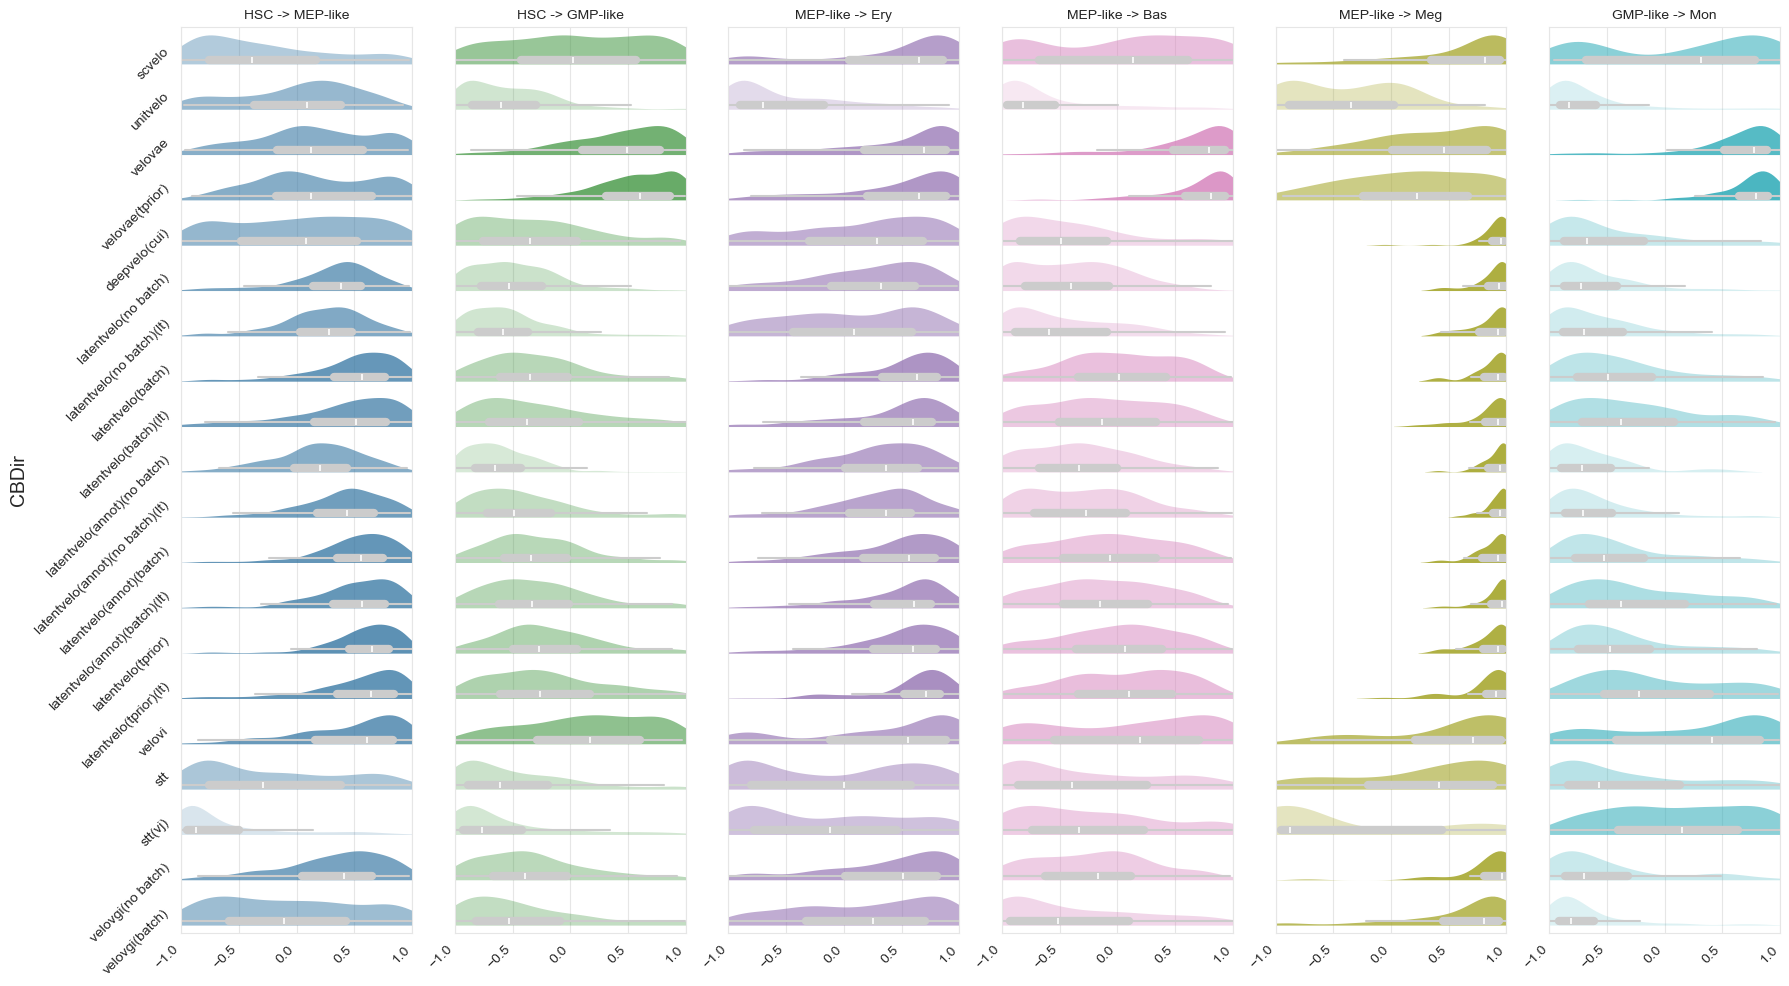

In [13]:
fig, axs = plt.subplots(nrows=1, ncols=len(results), sharex=True, sharey=True, figsize=(18, 10))
for i, (edge, result) in enumerate(results.items()):
    df = pd.DataFrame([(model, value) for model, values in result.items() for value in values], columns=["model", metric_name])
    model_means = {model: np.mean(values) for model, values in result.items()}
    violins = sns.violinplot(
        data=df, 
        x=metric_name, 
        y='model', 
        orient='h', 
        color=edge_color_map[edge], 
        split=True,
        width=0.8, 
        gap=0.2, 
        linewidth=0, 
        density_norm='width', 
        inner_kws=dict(box_width=6, whis_width=1.5, color=".8"), 
        ax=axs[i], 
    )
    for j, model in enumerate(result.keys()):
        violins.collections[j].set_alpha((model_means[model] + 1) / 2)
    axs[i].set_title(edge, fontsize=10)
    axs[i].set_xlim(-1, 1)
    axs[i].set_xlabel('')
    axs[i].set_ylabel('CBDir', fontsize=14)
    for label in axs[i].get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')
    for label in axs[i].get_yticklabels():
        label.set_rotation(45)
        label.set_ha('right')
plt.tight_layout()
plt.savefig(f'{save_dir}/{metric_name}.svg')
plt.show()

绘制ICCoh

In [14]:
metric_name = 'inner_cluster_coh'
models = ['scvelo', 'unitvelo', 'velovae', 'velovae_tprior', 'deepvelo_cui', 'latentvelo/no_batch', 'latentvelo/batch', 'latentvelo_annot/no_batch', 'latentvelo_annot/batch', 'latentvelo_tprior', 'velovi', 'stt', 'velovgi/no_batch', 'velovgi/batch']
results = {}
for cluster in clusters:
    result = {}
    for model in models:
        if model == 'scvelo':
            model_name = 'scvelo_dynamical'
        elif model.startswith('latentvelo'):
            model_name = 'latentvelo'
        elif model.startswith('topovelo'):
            model_name = 'topovelo'
        elif model.startswith('velovgi'):
            model_name = 'velovgi'
        elif model.startswith('velovae'):
            model_name = 'velovae'
        else:
            model_name = model
        metric_file = f'{base_dir}/{data}/{model}/{metric_name}_{model_name}_velocity.pkl'
        with open(metric_file, 'rb') as f:
            metric = pkl.load(f)
        if '/' in model:
            key_parts = model.split('/')
            key1 = key_parts[0]
            key2 = key_parts[-1].replace('_', ' ')
            key = f'{key1.split("_")[0]}({key1.split("_")[-1]})({key2})' if '_' in key1 else f'{key1}({key2})'
        else:
            key = f'{model.split("_")[0]}({model.split("_")[-1]})' if '_' in model else model
        result[key] = metric[cluster]
        if model == 'stt':
            stt_metric_file = f'{base_dir}/{data}/{model}/{metric_name}_vj.pkl'
            with open(stt_metric_file, 'rb') as f:
                stt_metric = pkl.load(f)
            result['stt(vj)'] = stt_metric[cluster]
        if model_name == 'latentvelo':
            ltv_metric_file = f'{base_dir}/{data}/{model}/{metric_name}_spliced_velocity.pkl'
            with open(ltv_metric_file, 'rb') as f:
                ltv_metric = pkl.load(f)
            result[f'{key}(lt)'] = ltv_metric[cluster]
    results[cluster] = result

In [15]:
colors = plt.cm.tab10(np.linspace(0, 1, len(results)))
cluster_color_map = dict(zip(results.keys(), colors))

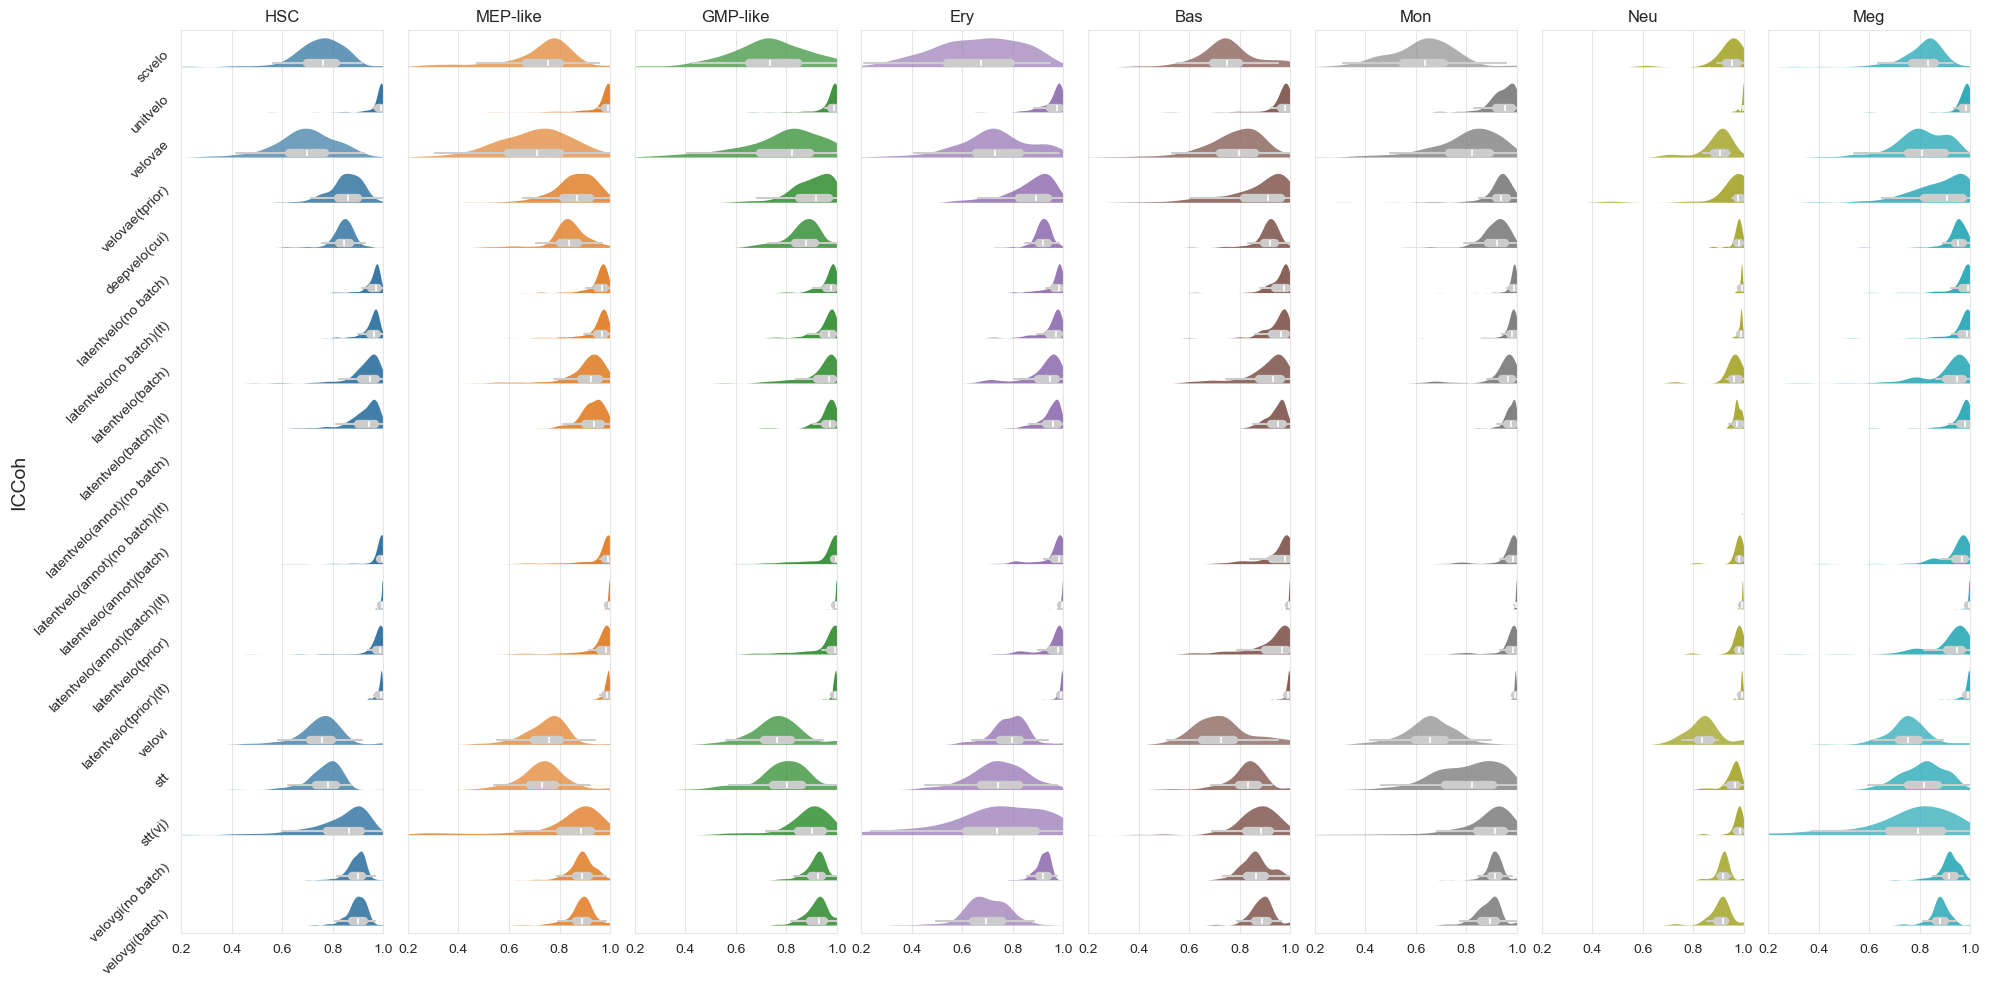

In [16]:
fig, axs = plt.subplots(nrows=1, ncols=len(results), sharex=True, sharey=True, figsize=(20, 10))
for i, (cluster, result) in enumerate(results.items()):
    df = pd.DataFrame([(model, value) for model, values in result.items() for value in values], columns=["model", metric_name])
    model_means = {model: np.mean(values) for model, values in result.items()}
    violins = sns.violinplot(
        data=df, 
        x=metric_name, 
        y='model', 
        orient='h', 
        color=cluster_color_map[cluster], 
        split=True, 
        width=0.8, 
        gap=0.2, 
        linewidth=0, 
        density_norm="count", 
        inner_kws=dict(box_width=6, whis_width=1.5, color=".8"),
        ax = axs[i], 
    )
    for j, model in enumerate(result.keys()):
        violins.collections[j].set_alpha(model_means[model])
    axs[i].set_title(cluster)
    axs[i].set_xlim(0.2, 1)
    axs[i].set_xlabel('')
    axs[i].set_ylabel('ICCoh', fontsize=14)
    # for label in axs[i].get_xticklabels():
    #     label.set_rotation(45)
    #     label.set_ha('right')
    for label in axs[i].get_yticklabels():
        label.set_rotation(45)
        label.set_ha('right')
plt.tight_layout()
plt.savefig(f'{save_dir}/{metric_name}.svg')
plt.show()

绘制k-CBDir

In [17]:
import re
import ast

In [18]:
k = 5
basis = 'umap'
metric_name = 'gen_cbdir_edge'
models = ['scvelo', 'unitvelo', 'velovae', 'velovae_tprior', 'deepvelo_cui', 'latentvelo/no_batch', 'latentvelo/batch', 'latentvelo_annot/no_batch', 'latentvelo_annot/batch', 'latentvelo_tprior', 'velovi', 'stt', 'velovgi/no_batch', 'velovgi/batch']
results = {}
for cluster_edge in cluster_edges:
    edge = f'{cluster_edge[0]} -> {cluster_edge[1]}'
    result = {'k': range(1, k+1)}
    for model in models: 
        if model == 'scvelo':
            model_name = 'scvelo_dynamical'
        elif model.startswith('latentvelo'):
            model_name = 'latentvelo'
        elif model.startswith('topovelo'):
            model_name = 'topovelo'
        elif model.startswith('velovgi'):
            model_name = 'velovgi'
        elif model.startswith('velovae'):
            model_name = 'velovae'
        else:
            model_name = model
        metric_file = f'{base_dir}/{data}/{model}/metric_redo.csv'
        if not os.path.exists(metric_file):
            metric_file = f'{base_dir}/{data}/{model}/metric.csv'
        metric = pd.read_csv(metric_file, index_col=0)
        idx_name = f'{metric_name}_{model_name}_velocity_{basis}_{edge}'
        if idx_name in metric.index:
            cbdir = metric.loc[metric.index == idx_name, '0'].values[0]
            if 'nan' not in cbdir:
                cbdir = re.sub(r'(?<=\d)\s+(?=\d|[-])', ', ', cbdir)
                cbdir = ast.literal_eval(cbdir)
                if '/' in model:
                    key_parts = model.split('/')
                    key1 = key_parts[0]
                    key2 = key_parts[-1].replace('_', ' ')
                    key = f'{key1.split("_")[0]}({key1.split("_")[-1]})({key2})' if '_' in key1 else f'{key1}({key2})'
                else:
                    key = f'{model.split("_")[0]}({model.split("_")[-1]})' if '_' in model else model
                result[key] = cbdir
        if model == 'stt': 
            stt_idx_name = f'{metric_name}_vj_{basis}_{edge}'
            if stt_idx_name in metric.index:
                cbdir = metric.loc[metric.index == stt_idx_name, '0'].values[0]
                if 'nan' not in cbdir:
                    cbdir = re.sub(r'(?<=\d)\s+(?=\d|[-])', ', ', cbdir)
                    cbdir = ast.literal_eval(cbdir)
                    result['stt(vj)'] = cbdir
        if model_name == 'latentvelo':
            ltv_idx_name = f'{metric_name}_spliced_velocity_{basis}_{edge}'
            if ltv_idx_name in metric.index:
                cbdir = metric.loc[metric.index == ltv_idx_name, '0'].values[0]
                if 'nan' not in cbdir:
                    cbdir = re.sub(r'\s+', ', ', cbdir)
                    cbdir = ast.literal_eval(cbdir)
                    result[f'{key}(lt)'] = cbdir
    results[edge] = result
results

{'HSC -> MEP-like': {'k': range(1, 6),
  'scvelo': [-0.257293135,
   -0.160652632,
   7.53757223e-05,
   0.0630085566,
   0.0841521369],
  'unitvelo': [0.00961227, 0.20231166, 0.40093863, 0.50452313, 0.54337434],
  'velovae': [0.15925123, 0.23878957, 0.37330064, 0.44815591, 0.46966659],
  'velovae(tprior)': [0.17665853,
   0.23697184,
   0.38491806,
   0.46358082,
   0.48508166],
  'deepvelo(cui)': [0.02360107,
   0.18164979,
   0.34253497,
   0.41770676,
   0.44528307],
  'latentvelo(no batch)': [0.30878141,
   0.46383315,
   0.66343241,
   0.73536644,
   0.76659905],
  'latentvelo(no batch)(lt)': [0.23331699,
   0.39288048,
   0.59732811,
   0.67344899,
   0.70723394],
  'latentvelo(batch)': [0.48942892,
   0.61163736,
   0.76843445,
   0.81958992,
   0.84235848],
  'latentvelo(batch)(lt)': [0.39116767,
   0.50983639,
   0.66426968,
   0.71808224,
   0.74294207],
  'latentvelo(annot)(no batch)': [0.17490788,
   0.33333587,
   0.5463054,
   0.62904242,
   0.66767907],
  'latentvelo(an

创建自定义调色盘

In [19]:
colors = {
    'scvelo': plt.cm.Set2(0 / 8),
    'unitvelo': plt.cm.Set2(1 / 8),
    'velovi': plt.cm.Set2(2 / 8),
    'velovae': plt.cm.Set2(3 / 8),
    'stt': plt.cm.Set2(4 / 8),
    'stt(vj)': plt.cm.Set2(4 / 8),
    'topovelo(KNN)': plt.cm.Set2(6 / 8),
    'topovelo(Delaunay)': plt.cm.Set3(1 / 12),
    'velovae(tprior)': plt.cm.Set3(7 / 12),
    'deepvelo(cui)': plt.cm.Set3(8 / 12),
    'latentvelo(tprior)': plt.cm.Set3(10 / 12),
    'latentvelo(no batch)': plt.cm.tab20b(12 / 20),
    'latentvelo(batch)': plt.cm.tab20b(15 / 20),
    'latentvelo(annot)(no batch)': plt.cm.tab20c(12 / 20),
    'latentvelo(annot)(batch)': plt.cm.tab20c(15 / 20),
    'latentvelo(tprior)(lt)': plt.cm.Set3(10 / 12),
    'latentvelo(no batch)(lt)': plt.cm.tab20b(12 / 20),
    'latentvelo(batch)(lt)': plt.cm.tab20b(15 / 20),
    'latentvelo(annot)(no batch)(lt)': plt.cm.tab20c(12 / 20),
    'latentvelo(annot)(batch)(lt)': plt.cm.tab20c(15 / 20),
    'velovgi(no batch)': plt.cm.tab20c(0 / 20),
    'velovgi(batch)': plt.cm.tab20c(3 / 20),
}
line_styles = {
    'scvelo': (1, 0),  # '-' 实线
    'unitvelo': (1, 0),  # '-' 实线
    'velovi': (1, 0),  # '-' 实线
    'velovae': (1, 0),  # '-' 实线
    'stt': (1, 0),  # '-' 实线
    'stt(vj)': (4, 2),  # '--' 虚线
    'topovelo(KNN)': (1, 0),  # '-' 实线
    'topovelo(Delaunay)': (1, 0),  # '-' 实线
    'velovae(tprior)': (1, 0),  # '-' 实线
    'deepvelo(cui)': (1, 0),  # '-' 实线
    'latentvelo(tprior)': (1, 0),  # '-' 实线
    'latentvelo(no batch)': (1, 0),  # '-' 实线
    'latentvelo(batch)': (1, 0),  # '-' 实线
    'latentvelo(annot)(no batch)': (1, 0),  # '-' 实线
    'latentvelo(annot)(batch)': (1, 0),  # '-' 实线
    'latentvelo(tprior)(lt)': (4, 2),  # '--' 虚线
    'latentvelo(no batch)(lt)': (4, 2),  # '--' 虚线
    'latentvelo(batch)(lt)': (4, 2),  # '--' 虚线
    'latentvelo(annot)(no batch)(lt)': (4, 2),  # '--' 虚线
    'latentvelo(annot)(batch)(lt)': (4, 2),  # '--' 虚线
    'velovgi(no batch)': (1, 0),  # '-' 实线
    'velovgi(batch)': (1, 0),  # '-' 实线
}

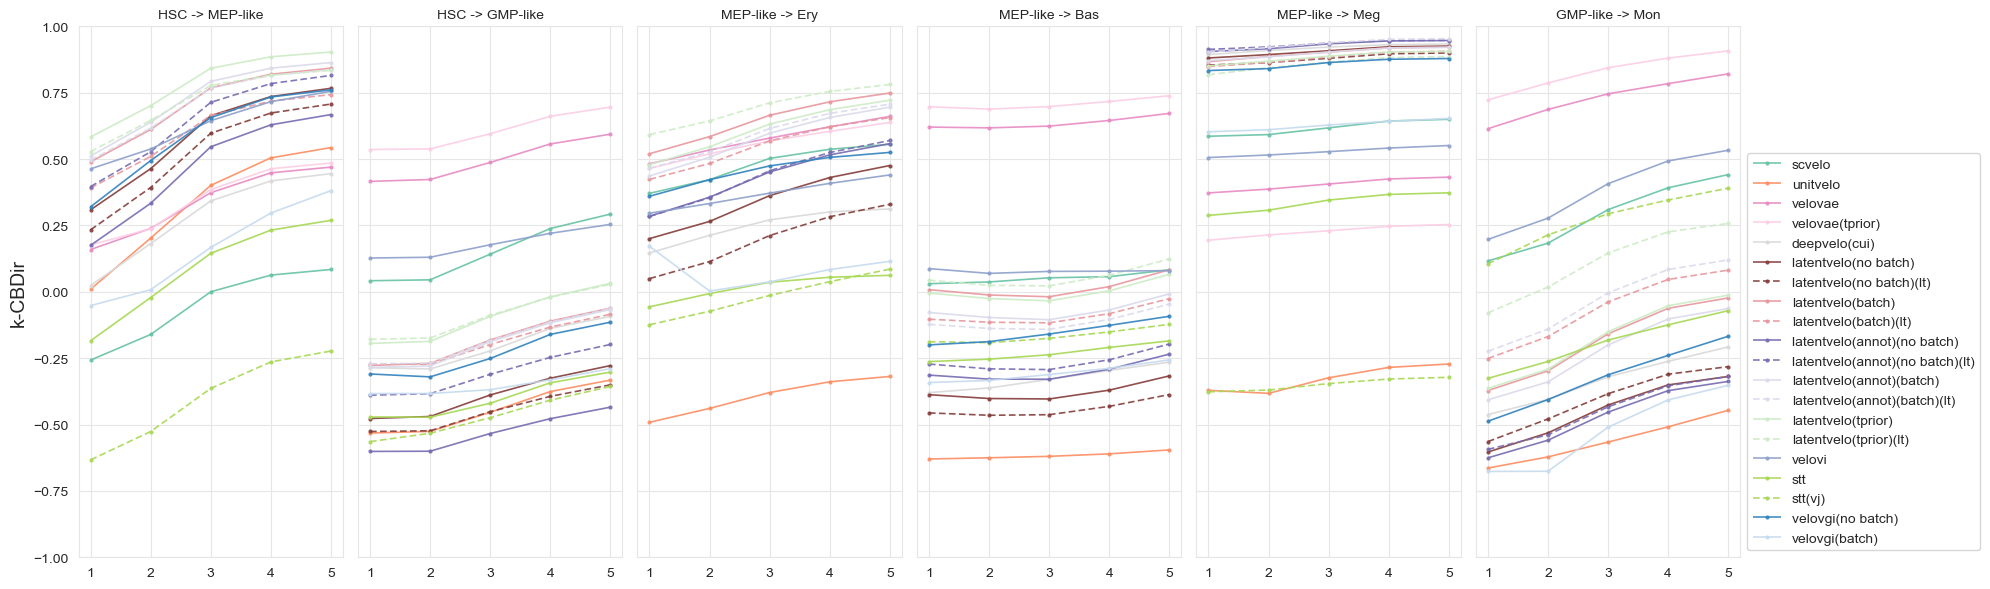

In [20]:
fig, axs = plt.subplots(nrows=1, ncols=len(results), sharex=True, sharey=True, figsize=(20, 6))
for i, (edge, result) in enumerate(results.items()):
    df = pd.DataFrame(result).melt(id_vars=['k'], var_name='model', value_name=metric_name)
    sns.lineplot(
        data=df, 
        x='k', 
        y=metric_name, 
        hue='model', 
        palette=colors, 
        style='model', 
        dashes=line_styles, 
        ax=axs[i], 
        linewidth=1.2,
        alpha=0.9,
        marker='o',
        markersize=3,
        markeredgewidth=0
    )
    axs[i].set_title(edge, fontsize=10)
    axs[i].set_xlabel('')
    axs[i].set_ylabel('k-CBDir', fontsize=14)
    axs[i].set_ylim(-1, 1)
    axs[i].get_legend().remove()

handles, labels = axs[0].get_legend_handles_labels()
plt.legend(handles, labels, loc='lower left', bbox_to_anchor=(1, 0))

plt.tight_layout()
plt.savefig(f'{save_dir}/{metric_name}.svg', bbox_inches='tight')
plt.show()

Time Score

In [21]:
metric_name = 'time_score_edge'
models = ['scvelo', 'unitvelo', 'velovae', 'velovae_tprior', 'deepvelo_cui', 'latentvelo/no_batch', 'latentvelo/batch', 'latentvelo_annot/no_batch', 'latentvelo_annot/batch', 'latentvelo_tprior', 'velovi', 'velovgi/no_batch', 'velovgi/batch']
results = {}
for cluster_edge in cluster_edges:
    edge = f'{cluster_edge[0]} -> {cluster_edge[1]}'
    result = {}
    for model in models: 
        if model == 'scvelo':
            model_name = 'scvelo_dynamical'
        elif model.startswith('latentvelo'):
            model_name = 'latentvelo'
        elif model.startswith('topovelo'):
            model_name = 'topovelo'
        elif model.startswith('velovgi'):
            model_name = 'velovgi'
        elif model.startswith('velovae'):
            model_name = 'velovae'
        else:
            model_name = model
        metric_file = f'{base_dir}/{data}/{model}/metric_redo.csv'
        if not os.path.exists(metric_file):
            metric_file = f'{base_dir}/{data}/{model}/metric.csv'
        metric = pd.read_csv(metric_file, index_col=0)
        if '/' in model:
            key_parts = model.split('/')
            key1 = key_parts[0]
            key2 = key_parts[-1].replace('_', ' ')
            key = f'{key1.split("_")[0]}({key1.split("_")[-1]})({key2})' if '_' in key1 else f'{key1}({key2})'
        else:
            key = f'{model.split("_")[0]}({model.split("_")[-1]})' if '_' in model else model
        if model_name not in ['velovi', 'velovgi']:
            tkey = 'pred_t'
            idx_name = f'{metric_name}_{tkey}_{edge}'
            if idx_name in metric.index:
                t_score = float(metric.loc[metric.index == idx_name, '0'].values[0])
                result[key] = t_score
        if model_name in ['scvelo_dynamical', 'velovi', 'velovgi']:
            t_gene_key = 'fit_t'
            idx_name = f'{metric_name}_{t_gene_key}_{edge}'
            if idx_name in metric.index:
                t_score = float(metric.loc[metric.index == idx_name, '0'].values[0])
                result[f'{key}(avg)' if model == 'scvelo' else key] = t_score
    results[edge] = result
results

{'HSC -> MEP-like': {'scvelo': 0.4680730527642639,
  'scvelo(avg)': 0.5424004872072684,
  'unitvelo': 0.3817849631407873,
  'velovae': 0.6556832586234979,
  'velovae(tprior)': 0.6272297876257852,
  'deepvelo(cui)': 0.45438451134102387,
  'latentvelo(no batch)': 0.5115322243702776,
  'latentvelo(batch)': 0.6594364541508219,
  'latentvelo(annot)(no batch)': 0.6111831063712264,
  'latentvelo(annot)(batch)': 0.6345166521495896,
  'latentvelo(tprior)': 0.6445298945564502,
  'velovi': 0.4946640890003045,
  'velovgi(no batch)': 0.6444732425484906,
  'velovgi(batch)': 0.5427333177540311},
 'HSC -> GMP-like': {'scvelo': 0.39046010975094975,
  'scvelo(avg)': 0.5896399927636736,
  'unitvelo': 0.38828921184345416,
  'velovae': 0.6626263844499387,
  'velovae(tprior)': 0.6664455566946069,
  'deepvelo(cui)': 0.381997628093027,
  'latentvelo(no batch)': 0.30318197350700515,
  'latentvelo(batch)': 0.38601780940320407,
  'latentvelo(annot)(no batch)': 0.31701139721401433,
  'latentvelo(annot)(batch)': 0

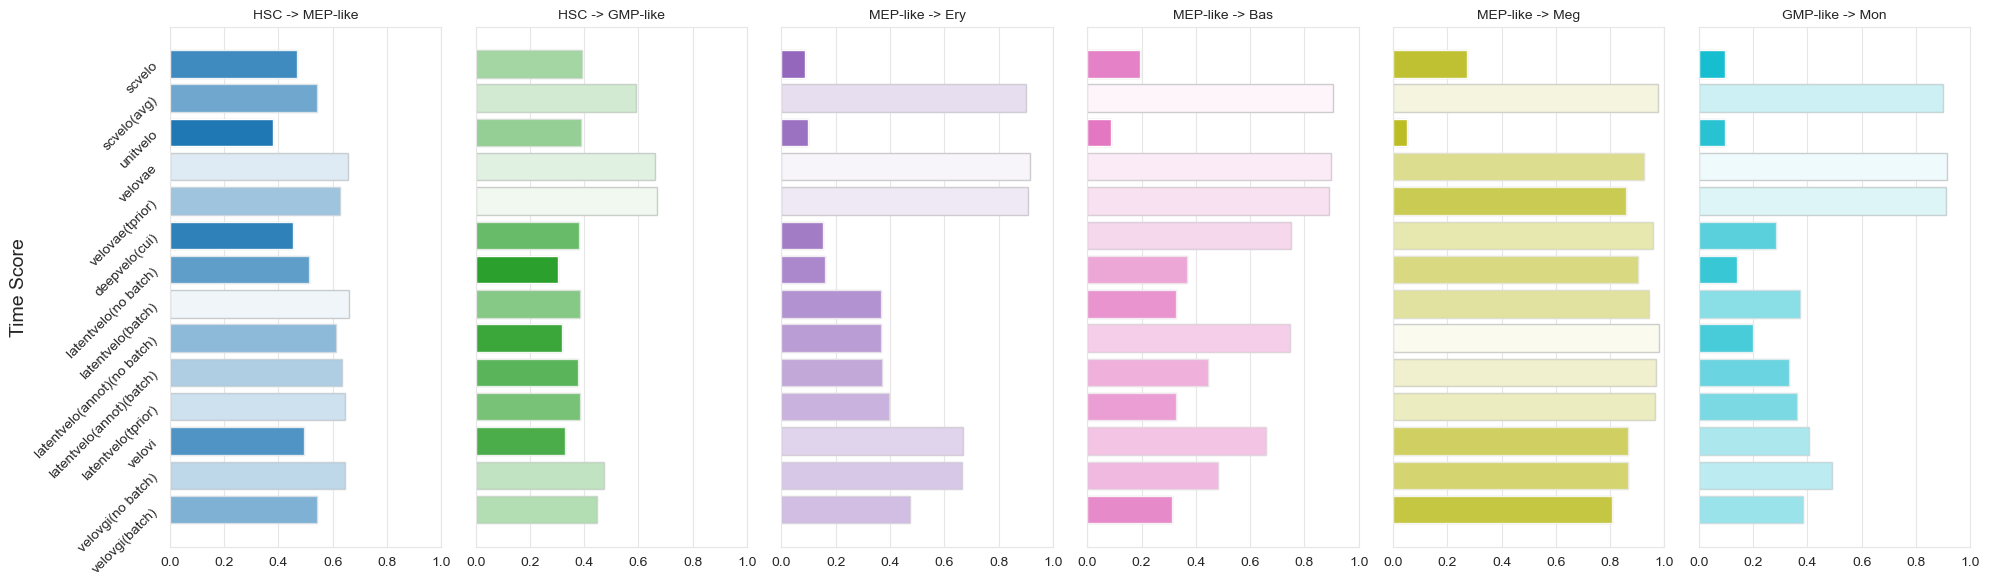

In [22]:
fig, axs = plt.subplots(nrows=1, ncols=len(results), sharex=True, sharey=True, figsize=(20, 6))
for i, (edge, result) in enumerate(results.items()):
    df = pd.DataFrame(list(result.items()), columns=['model', metric_name])
    sns.barplot(data=df, x=metric_name, y='model', ax=axs[i], orient='h', color='white', edgecolor='.8', linewidth=1)
    df['rank'] = df[metric_name].rank(ascending=False)
    for j, (model, value, rank) in enumerate(zip(df['model'], df[metric_name], df['rank'])):
        axs[i].barh(model, value, color=edge_color_map[edge], alpha=rank / len(df['rank']))
    axs[i].set_title(edge, fontsize=10)
    axs[i].set_xlabel('')
    axs[i].set_ylabel('Time Score', fontsize=14)
    axs[i].set_xlim(0, 1)
    for label in axs[i].get_yticklabels():
        label.set_rotation(45)
        label.set_ha('right')
plt.tight_layout()
plt.savefig(f'{save_dir}/{metric_name}.svg', bbox_inches='tight')
plt.show()